# Project 6: Community-Aware Food Recommendation System

- **Student name - id:** Binh Nguyen - 2406812 
- **Dataset:** Food.com - RAW_recipes.csv and RAW_interactions.csv



## 0. Setup & Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
import ast
# might need: pip install python-louvain
import community as community_louvain
# import warnings

from collections import Counter, defaultdict
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from itertools import islice

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Load and Preprocess Data

In [3]:
# Load the datasets
recipes_raw = pd.read_csv('RAW_recipes.csv')
interactions_raw = pd.read_csv('RAW_interactions.csv')

print(f"Recipes data: {recipes_raw.shape[0]} rows, {recipes_raw.shape[1]} columns")
print(f"Interactions data: {interactions_raw.shape[0]} rows, {interactions_raw.shape[1]} columns")

Recipes data: 231637 rows, 12 columns
Interactions data: 1132367 rows, 5 columns


In [6]:
recipes_raw.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


In [7]:
interactions_raw.head(3)

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...


In [7]:
# Clean interactions
interactions = interactions_raw[['user_id', 'recipe_id', 'rating', 'date']].dropna() # drop nulls
interactions = interactions[interactions['rating'] > 0] # ignore unrated
interactions['date'] = pd.to_datetime(interactions['date'], errors='coerce')

# Subsample for tractability 
# Too many users for cosine sim, keep only 3,000 most active ones (min 5 ratings/user)
MIN_RATINGS = 5 
MAX_USERS = 3000

user_counts = interactions['user_id'].value_counts()
active_users = user_counts[user_counts >= MIN_RATINGS].index

if len(active_users) > MAX_USERS:
    # Keep the most active users
    active_users = user_counts.nlargest(MAX_USERS).index
    print(f"Subsampled to top {MAX_USERS} most active users.")

interactions = interactions[interactions['user_id'].isin(active_users)]

# Map to usrs and recipes to contiguous integers
unique_users   = interactions['user_id'].unique()
unique_recipes = interactions['recipe_id'].unique()
user_idx   = {u: i for i, u in enumerate(unique_users)}
recipe_idx = {r: i for i, r in enumerate(unique_recipes)}

interactions['user_ix']   = interactions['user_id'].map(user_idx)
interactions['recipe_ix'] = interactions['recipe_id'].map(recipe_idx)

print(f"\nFiltered interactions: {len(interactions)}")
print(f"Unique users: {len(unique_users)}")
print(f"Unique recipes: {len(unique_recipes)}")

Subsampled to top 3000 most active users.

Filtered interactions: 606635
Unique users: 3000
Unique recipes: 185009


In [13]:
# Train / test split (80% / 20%)
train_df, test_df = train_test_split(interactions, test_size=0.2, random_state=RANDOM_SEED)
print(f"Train: {len(train_df)}")
print(f"Test: {len(test_df)}")

# Ground-truth: recipes each user rated in the test set
test_user_items = test_df.groupby('user_id')['recipe_id'].apply(set).to_dict()

Train: 485308
Test: 121327


## Task 1 - User Interaction Network Construction

In [17]:
# Build user-recipe rating matrix from TRAINING data only
n_users = len(unique_users)
n_recipes = len(unique_recipes)

rows = train_df['user_ix'].values
cols = train_df['recipe_ix'].values
vals = train_df['rating'].values.astype(float)

rating_matrix = csr_matrix((vals, (rows, cols)), shape=(n_users, n_recipes))
print(f"Rating matrix shape: {rating_matrix.shape}")
print(f"Sparsity: {1 - rating_matrix.nnz / (n_users * n_recipes):.4%}")

Rating matrix shape: (3000, 185009)
Sparsity: 99.9126%


In [19]:
# Cosine similarity between users 
similarity_matrix = cosine_similarity(rating_matrix, dense_output=True)
np.fill_diagonal(similarity_matrix, 0)  # remove self-loops
print(f"Similarity matrix's shape: {similarity_matrix.shape}")

Similarity matrix's shape: (3000, 3000)


In [21]:
# Build NetworkX graph with similarity threshold 
SIMILARITY_THRESHOLD = 0.05 # edge if cosine_sim >= threshold

G = nx.Graph()
G.add_nodes_from(range(n_users))

# Vectorised edge extraction
upper_i, upper_j = np.triu_indices(n_users, k=1)
similarity_vals = similarity_matrix[upper_i, upper_j]
mask = similarity_vals >= SIMILARITY_THRESHOLD
edges = list(zip(upper_i[mask].tolist(),
                 upper_j[mask].tolist(),
                 similarity_vals[mask].tolist()))
G.add_weighted_edges_from(edges)

# Map node id -> original user_id for later use
ix_to_user = {i: u for u, i in user_idx.items()}
nx.set_node_attributes(G, ix_to_user, 'user_id')

print(f"Graph: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Density: {nx.density(G):.4f}")

Graph: 3000 nodes and 22249 edges
Density: 0.0049


## Task 2 - Network Structural Analysis

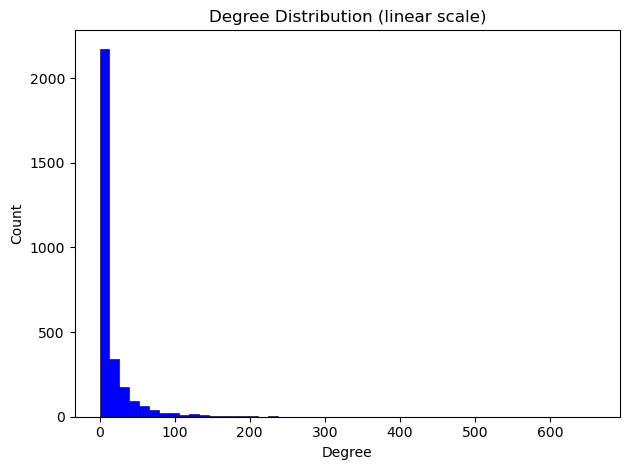

In [23]:
# Degree distribution
degrees = [d for _, d in G.degree()]

# Linear scale
plt.hist(degrees, bins=50, color='blue', edgecolor='black', linewidth=0.4)
plt.title('Degree Distribution (linear scale)')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.savefig("linear_degree_distribution.png")
plt.tight_layout()
plt.show()

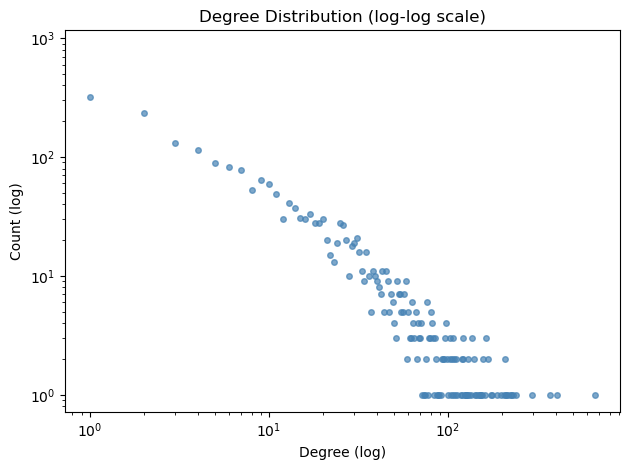

In [25]:
# Log-log scale
degree_counts = Counter(degrees)
x_vals = sorted(degree_counts.keys())
y_vals = [degree_counts[k] for k in x_vals]
plt.loglog(x_vals, y_vals, 'o', markersize=4, color='steelblue', alpha=0.7)
plt.title('Degree Distribution (log-log scale)')
plt.xlabel('Degree (log)')
plt.ylabel('Count (log)')
plt.savefig("loglog_degree_distribution.png")
plt.tight_layout()
plt.show()

In [27]:
# Statistics
print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Max degree: {np.max(degrees)}")
print(f"Median degree: {np.median(degrees):.1f}")

Mean degree: 14.83
Max degree: 660
Median degree: 3.0


In [29]:
# Compute betweeness and closeness centrality 
# Only works on connected graph, so use largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Largest CC: {G_lcc.number_of_nodes()} nodes ({100*G_lcc.number_of_nodes()/n_users:.1f}% of all users)")

# Full is too slow, just use approximation
k_sample = min(500, G_lcc.number_of_nodes())
between_centrality = nx.betweenness_centrality(G_lcc, k=k_sample, normalized=True, seed=RANDOM_SEED)

# Closeness
close_centrality = nx.closeness_centrality(G_lcc)

Largest CC: 2138 nodes (71.3% of all users)


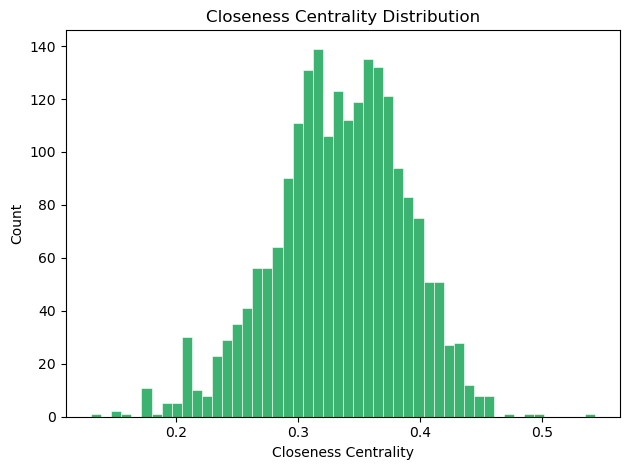

In [31]:
# Visualize closeness centrality distribution
plt.hist(list(close_centrality.values()), bins=50, color='mediumseagreen', edgecolor='white', linewidth=0.4)
plt.title('Closeness Centrality Distribution')
plt.xlabel('Closeness Centrality')
plt.ylabel('Count')
plt.savefig("closeness_centrality_distribution.png")
plt.tight_layout()
plt.show()

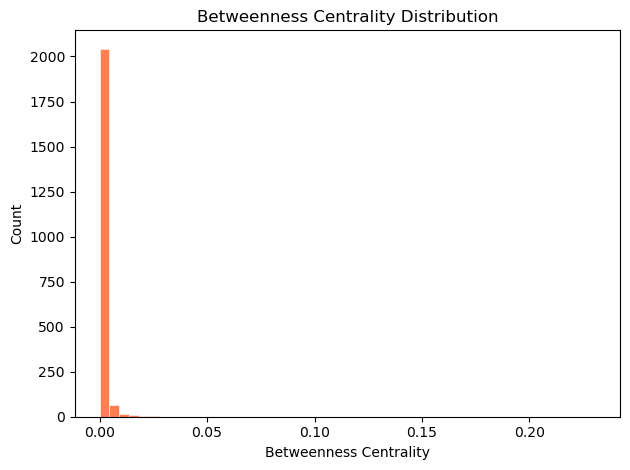

In [33]:
# Visualize betweeness centrality distribution
plt.hist(list(between_centrality.values()), bins=50, color='coral', edgecolor='white', linewidth=0.4)
plt.title('Betweenness Centrality Distribution')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Count')
plt.savefig("betweeness_centrality_distribution.png")
plt.tight_layout()
plt.show()

In [35]:
# Statistics
print(f"Closeness Centrality's mean: {np.mean(list(close_centrality.values())):.4f}")
print(f"Betweenness Centrality's mean: {np.mean(list(between_centrality.values())):.6f}")
print(f"Average Clustering Coefficient: {nx.average_clustering(G)}")
print(f"Network Diameter: {nx.diameter(G_lcc)}")

Closeness Centrality's mean: 0.3339
Betweenness Centrality's mean: 0.000970
Average Clustering Coefficient: 0.1452200882246129
Network Diameter: 11


## Task 3 - Community Detection

In [37]:
# Louvain Algorithm 
louvain_partition = community_louvain.best_partition(G, weight='weight', random_state=RANDOM_SEED)
louvain_modularity = community_louvain.modularity(louvain_partition, G, weight='weight')

n_louvain_communities = len(set(louvain_partition.values()))
print(f"Louvain communities: {n_louvain_communities}")
print(f"Louvain modularity: {louvain_modularity:.4f}")

# Store community label as node attribute
nx.set_node_attributes(G, louvain_partition, 'louvain_community')

Louvain communities: 858
Louvain modularity: 0.2429


In [41]:
# Girvan-Newman Algorithm
# GN is O(m^3), so it is really slow on big graphs, run on subgraph instead.
GN_NODES = 300
gn_nodes = list(G_lcc.nodes())[:GN_NODES]
G_gn = G_lcc.subgraph(gn_nodes).copy()

gn_generator = nx.community.girvan_newman(G_gn)

# Keep iterating until getting roughly the same as louvain
target_k = min(n_louvain_communities, 10)  # cap at 10
gn_communities = None
for communities in islice(gn_generator, target_k):
    gn_communities = communities

gn_communities = [list(c) for c in gn_communities]

# Build partition dict for GN subgraph
gn_partition = {}
for comm_id, comm in enumerate(gn_communities):
    for node in comm:
        gn_partition[node] = comm_id

gn_modularity = nx.community.modularity(G_gn, [set(c) for c in gn_communities])
print(f"Girvan-Newman communities: {len(gn_communities)}")
print(f"Girvan-Newman modularity: {gn_modularity:.4f}")

Girvan-Newman communities: 103
Girvan-Newman modularity: 0.2945


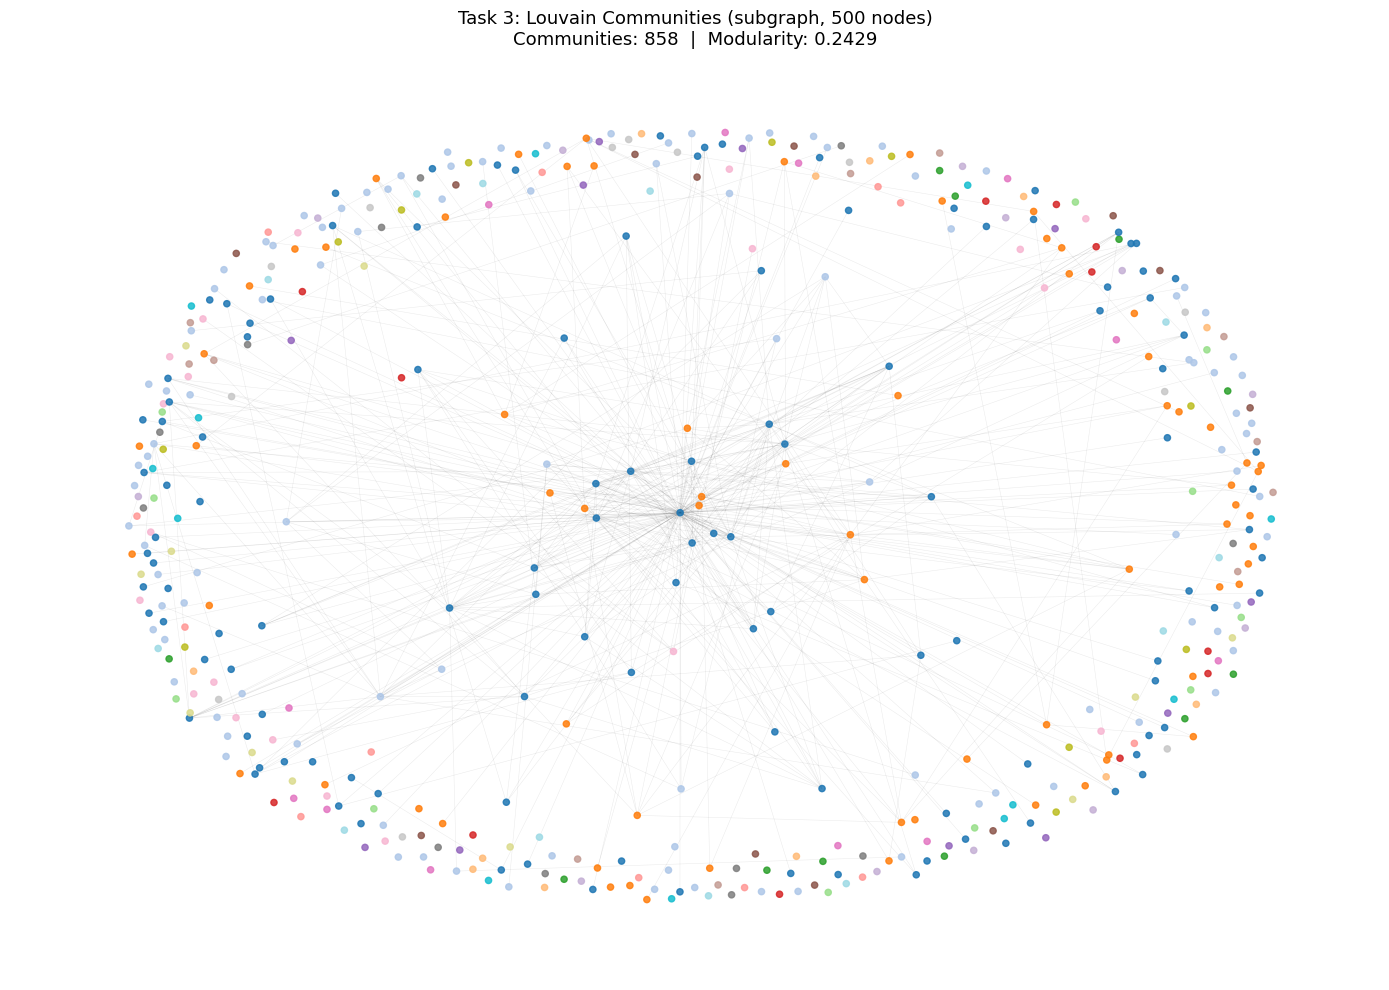

In [43]:
# Visualise Louvain communities (spring layout on subgraph) 
VIZ_NODES = 500
viz_nodes = list(G.nodes())[:VIZ_NODES]
G_viz = G.subgraph(viz_nodes).copy()

comm_colors_louvain = [louvain_partition.get(n, 0) for n in G_viz.nodes()]
pos = nx.spring_layout(G_viz, seed=RANDOM_SEED, k=0.3)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_viz, pos, node_color=comm_colors_louvain,
                       cmap=cm.tab20, node_size=20, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_viz, pos, alpha=0.08, width=0.4, ax=ax)
ax.set_title(f'Task 3: Louvain Communities (subgraph, {VIZ_NODES} nodes)\n'
             f'Communities: {n_louvain_communities}  |  Modularity: {louvain_modularity:.4f}',
             fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('task3_louvain_communities.png', bbox_inches='tight')
plt.show()

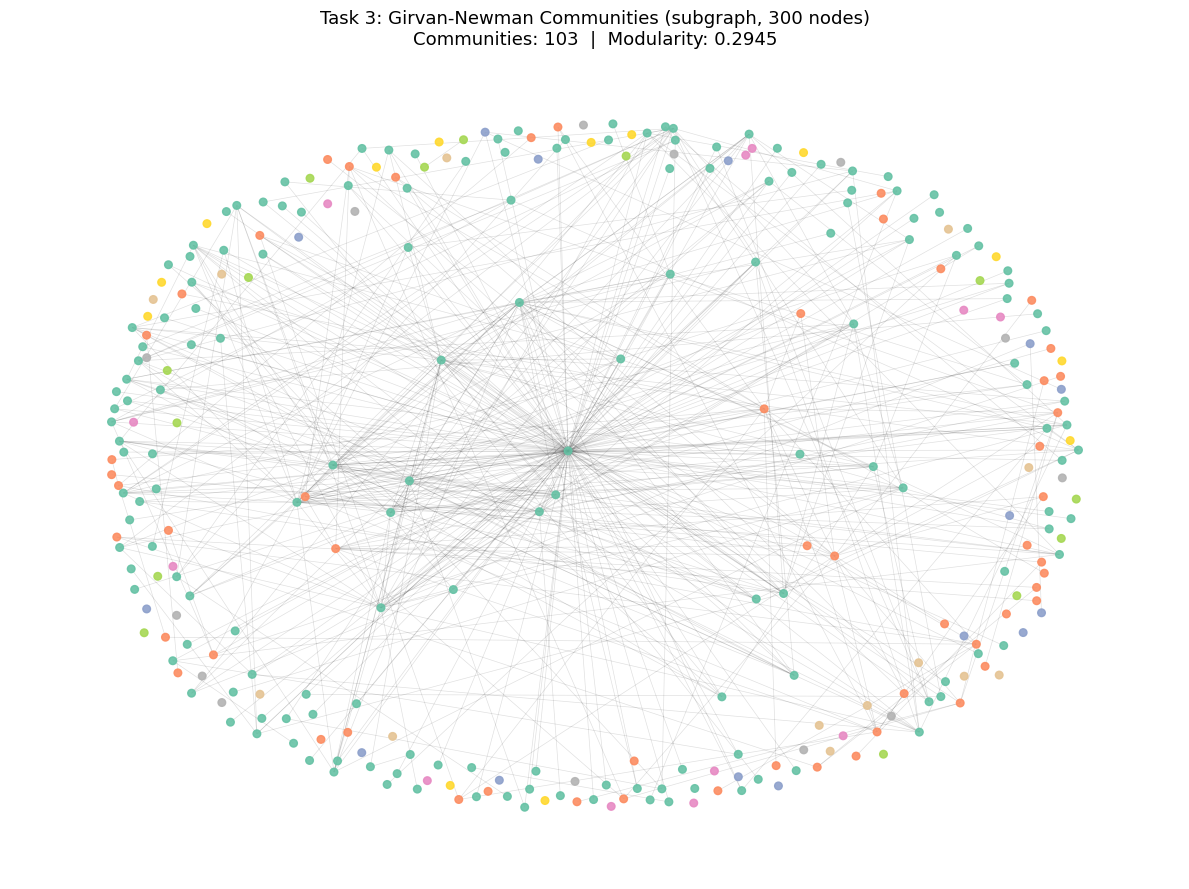

In [45]:
# Visualise Girvan-Newman communities
gn_colors = [gn_partition.get(n, 0) for n in G_gn.nodes()]
pos_gn = nx.spring_layout(G_gn, seed=RANDOM_SEED, k=0.5)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_nodes(G_gn, pos_gn, node_color=gn_colors,
                       cmap=cm.Set2, node_size=30, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_gn, pos_gn, alpha=0.12, width=0.5, ax=ax)
ax.set_title(f'Task 3: Girvan-Newman Communities (subgraph, {GN_NODES} nodes)\n'
             f'Communities: {len(gn_communities)}  |  Modularity: {gn_modularity:.4f}',
             fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('task3_girvan_newman_communities.png', bbox_inches='tight')
plt.show()

In [47]:
# Modularity comparison table
modularity_comparison_df = pd.DataFrame({
    'Algorithm': ['Louvain', 'Girvan-Newman (subgraph)'],
    'Communities': [n_louvain_communities, len(gn_communities)],
    'Modularity': [round(louvain_modularity, 4), round(gn_modularity, 4)]
})
print(modularity_comparison_df.to_string(index=False))

               Algorithm  Communities  Modularity
                 Louvain          858      0.2429
Girvan-Newman (subgraph)          103      0.2945


## Task 4 - Community Profiling

In [49]:
# Map each user_id to their Louvain community
user_to_community = {
    ix_to_user[node]: comm
    for node, comm in louvain_partition.items()
    if node in ix_to_user
}

# Add community column to training data
train_df = train_df.copy()
train_df['community'] = train_df['user_id'].map(user_to_community)
train_df = train_df.dropna(subset=['community'])
train_df['community'] = train_df['community'].astype(int)

print(f"Training rows with community label: {len(train_df)}")

Training rows with community label: 485308


In [51]:
# Parse ingredients and tags from recipes
def safe_parse_list(val):
    """Parse list fields from csv."""
    if pd.isna(val):
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except Exception:
        return []

recipes = recipes_raw[['id', 'name', 'tags', 'ingredients']].copy()
recipes = recipes.rename(columns={'id': 'recipe_id'})
recipes['tags_list'] = recipes['tags'].apply(safe_parse_list)
recipes['ingredients_list'] = recipes['ingredients'].apply(safe_parse_list)
print("Recipes parsed.")

Recipes parsed.


In [53]:
# Merge community label into training interactions -> join with recipes
train_with_recipe = train_df.merge(recipes[['recipe_id', 'tags_list', 'ingredients_list']],
                                    on='recipe_id', 
                                    how='left')

def top_k_items(series_of_lists, k=10):
    """Get most common items across all lists."""
    counter = Counter(item for lst in series_of_lists if isinstance(lst, list) for item in lst)
    return counter.most_common(k)

# Profile each community
community_profiles = {}
for comm_id, grp in train_with_recipe.groupby('community'):
    profile = {
        'size': len(grp['user_id'].unique()),
        'n_interactions': len(grp),
        'avg_rating': grp['rating'].mean(),
        'activity_level': len(grp) / len(grp['user_id'].unique()), # interactions per user
        'top_ingredients': top_k_items(grp['ingredients_list'], 10),
        'top_tags': top_k_items(grp['tags_list'], 10),
    }
    community_profiles[comm_id] = profile

# Summary table
profile_summary = pd.DataFrame([
    {'Community': k,
     'Users': v['size'],
     'Interactions': v['n_interactions'],
     'Avg Rating': round(v['avg_rating'], 3),
     'Activity (int/user)': round(v['activity_level'], 2)}
    for k, v in community_profiles.items()
]).sort_values('Users', ascending=False)

print(f"\nTop 10 communities by size:")
print(profile_summary.head(10).to_string(index=False))


Top 10 communities by size:
 Community  Users  Interactions  Avg Rating  Activity (int/user)
         1    339         89104       4.685               262.84
        32    271         21410       4.645                79.00
        21    266         19603       4.664                73.70
        19    243         18648       4.630                76.74
        23    222         16996       4.631                76.56
         0    189         13910       4.619                73.60
        14    188         13388       4.668                71.21
        18    179         14235       4.649                79.53
       163     99          7842       4.770                79.21
        17     82          5879       4.859                71.70


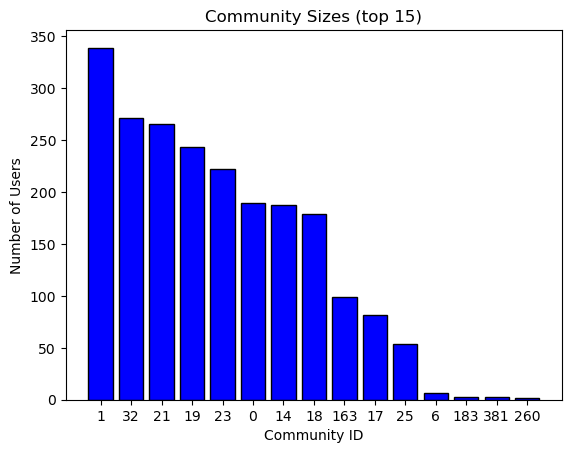

In [55]:
top_communities = profile_summary.head(15)

# Visualize top 15 community sizes
plt.bar(top_communities['Community'].astype(str), top_communities['Users'],
            color='blue', edgecolor='black')
plt.title('Community Sizes (top 15)')
plt.xlabel('Community ID')
plt.ylabel('Number of Users')
plt.savefig("community_sizes.png")

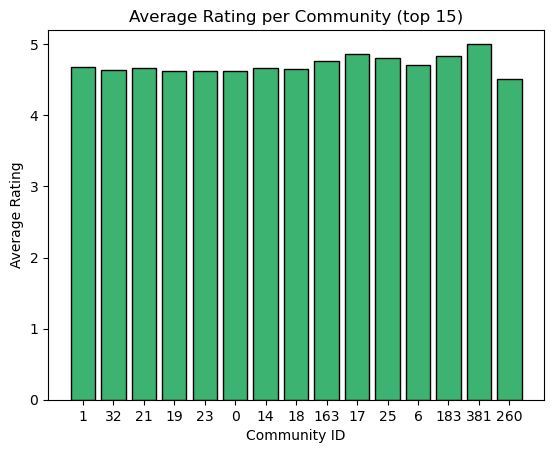

In [57]:
plt.bar(top_communities['Community'].astype(str), top_communities['Avg Rating'],
            color='mediumseagreen', edgecolor='black')
plt.title('Average Rating per Community (top 15)')
plt.xlabel('Community ID')
plt.ylabel('Average Rating')
plt.ylim(0, 5.2)
plt.savefig("avg_rating.png")
plt.show()

In [59]:
# Print top ingredients and tags for the 3 largest communities
top3_comms = profile_summary.head(3)['Community'].tolist()
for cid in top3_comms:
    p = community_profiles[cid]
    print(f"Community ID: {cid} | (users: {p['size']}, avg_rating: {p['avg_rating']:.2f})")
    print("- Top ingredients:", [x[0] for x in p['top_ingredients'][:5]])
    print("- Top tags:", [x[0] for x in p['top_tags'][:5]])

Community ID: 1 | (users: 339, avg_rating: 4.68)
- Top ingredients: ['salt', 'butter', 'sugar', 'onion', 'water']
- Top tags: ['preparation', 'time-to-make', 'course', 'dietary', 'main-ingredient']
Community ID: 32 | (users: 271, avg_rating: 4.65)
- Top ingredients: ['salt', 'butter', 'sugar', 'onion', 'eggs']
- Top tags: ['preparation', 'time-to-make', 'course', 'dietary', 'main-ingredient']
Community ID: 21 | (users: 266, avg_rating: 4.66)
- Top ingredients: ['salt', 'butter', 'sugar', 'onion', 'eggs']
- Top tags: ['preparation', 'time-to-make', 'course', 'dietary', 'main-ingredient']


## Task 5 - Community-Based Recommendation

In [61]:
# For each community, rank recipes by number of ratings (training set)
community_popular = {}
for comm_id, grp in train_df.groupby('community'):
    # Count ratings per recipe within the community
    recipe_counts = grp['recipe_id'].value_counts()
    community_popular[comm_id] = recipe_counts  # Series: recipe_id -> count

# Global popularity (all training users)
global_popular = train_df['recipe_id'].value_counts()  # recipe_id -> count

# Recipes already seen (training) per user
user_seen = train_df.groupby('user_id')['recipe_id'].apply(set).to_dict()

print(f"Communities with popularity data: {len(community_popular)}")

Communities with popularity data: 858


In [63]:
def recommend_community_based(user_id, K, user_to_community, community_popular, user_seen):
    """Recommend top K recipes from user's community, skip already seen items."""
    comm = user_to_community.get(user_id)
    if comm is None or comm not in community_popular:
        return []  # user not in any community
    
    seen = user_seen.get(user_id, set())
    candidates = community_popular[comm]
    recs = [rid for rid in candidates.index if rid not in seen]
    return recs[:K]


def recommend_global_popularity(user_id, K, global_popular, user_seen):
    """Recommend top K recipes for user_id based on global popularity, skip already seen items."""
    seen = user_seen.get(user_id, set())
    recs = [rid for rid in global_popular.index if rid not in seen]
    return recs[:K]

## Task 6 - Evaluation: Precision@K and Recall@K

In [65]:
def precision_at_k(recommended, relevant, k):
    """Proportion of recommended items in the top K that are relevant."""
    if k == 0:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / k


def recall_at_k(recommended, relevant, k):
    """Proportion of relevant items successfully recommended in top K."""
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / len(relevant)


def evaluate(users, K_list, rec_fn, test_user_items):
    """Run evaluation for multiple K values, returns avg precision and recall."""
    results = {K: {'precision': [], 'recall': []} for K in K_list}

    for user_id in users:
        relevant = test_user_items.get(user_id, set())
        if not relevant:
            continue
        max_K = max(K_list)
        recs = rec_fn(user_id, max_K)
        for K in K_list:
            results[K]['precision'].append(precision_at_k(recs, relevant, K))
            results[K]['recall'].append(recall_at_k(recs, relevant, K))

    avg_results = {}
    for K in K_list:
        avg_results[K] = {
            'Precision@K': np.mean(results[K]['precision']),
            'Recall@K': np.mean(results[K]['recall'])
        }
    return avg_results

In [69]:
# Evaluate on users who appear in both test set and have a community assignment
eval_users = [
    uid for uid in test_user_items
    if uid in user_to_community and uid in user_seen
]

K_LIST = [5, 10, 20]

# Community-based recommendation
comm_rec_fn = lambda uid, k: recommend_community_based(uid, k, user_to_community, community_popular, user_seen)

# Global popularity baseline
global_rec_fn = lambda uid, k: recommend_global_popularity(uid, k, global_popular, user_seen)

comm_results = evaluate(eval_users, K_LIST, comm_rec_fn, test_user_items)

global_results = evaluate(eval_users, K_LIST, global_rec_fn, test_user_items)

In [71]:
# Results table 
rows_table = []
for K in K_LIST:
    rows_table.append({
        'K': K,
        'Community Precision@K': round(comm_results[K]['Precision@K'], 6),
        'Community Recall@K': round(comm_results[K]['Recall@K'], 6),
        'Global Baseline Precision@K': round(global_results[K]['Precision@K'], 6),
        'Global Baseline Recall@K': round(global_results[K]['Recall@K'], 6),
    })

results_df = pd.DataFrame(rows_table)
print("Evaluation Results (avg across all evaluated users):")
print(results_df.to_string(index=False))

Evaluation Results (avg across all evaluated users):
 K  Community Precision@K  Community Recall@K  Global Baseline Precision@K  Global Baseline Recall@K
 5               0.026533            0.005898                     0.028400                  0.006053
10               0.022367            0.009976                     0.026000                  0.010790
20               0.018033            0.015626                     0.022183                  0.018571


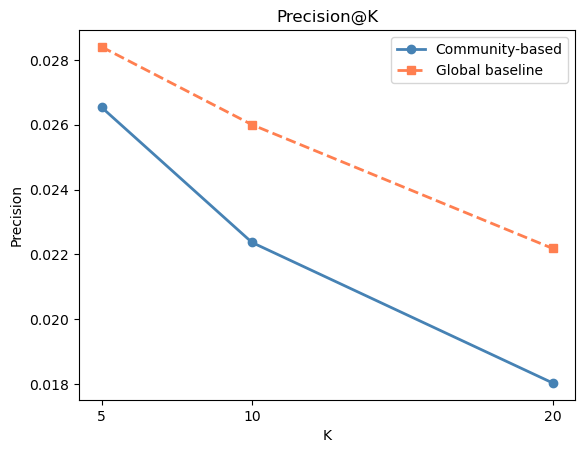

In [73]:
#  Visualize Precision@K
plt.plot(K_LIST, [comm_results[K]['Precision@K'] for K in K_LIST],
             'o-', color='steelblue',  label='Community-based', linewidth=2)
plt.plot(K_LIST, [global_results[K]['Precision@K'] for K in K_LIST],
             's--', color='coral', label='Global baseline', linewidth=2)
plt.title('Precision@K')
plt.xlabel('K')
plt.ylabel('Precision')
plt.xticks(K_LIST)
plt.legend()
plt.savefig("precisionK.png")

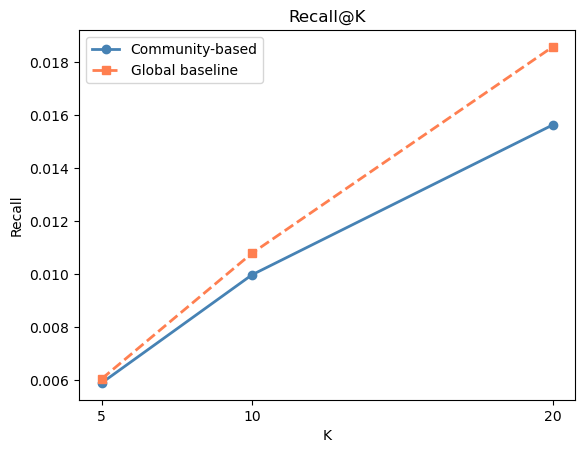

In [75]:
# Visualize Recall@K
plt.plot(K_LIST, [comm_results[K]['Recall@K'] for K in K_LIST],
             'o-', color='steelblue', label='Community-based', linewidth=2)
plt.plot(K_LIST, [global_results[K]['Recall@K'] for K in K_LIST],
             's--', color='coral', label='Global baseline', linewidth=2)
plt.title('Recall@K')
plt.xlabel('K')
plt.ylabel('Recall')
plt.xticks(K_LIST)
plt.legend()
plt.savefig("recallK.png")
plt.show()


## Task 7 - Comparison Analysis

In [77]:
# Side-by-side bar chart: community vs global 
x = np.arange(len(K_LIST))
width = 0.2

def visualize_comparison(metric):
    '''Bar chart comparison.'''
    comm_vals = [comm_results[K][metric] for K in K_LIST]
    global_vals = [global_results[K][metric] for K in K_LIST]

    bars1 = plt.bar(x - width/2, comm_vals, width, label='Community-based', color='steelblue')
    bars2 = plt.bar(x + width/2, global_vals, width, label='Global baseline', color='coral')
    plt.title(metric)
    plt.xticks(x, [f'K={k}' for k in K_LIST])
    plt.ylabel(metric)
    plt.legend()
    # Annotate bars
    for bar in bars1:
        plt.annotate(f'{bar.get_height():.5f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
    for bar in bars2:
        plt.annotate(f'{bar.get_height():.5f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
    plt.savefig(f"{metric}_comparison_bar.png")
    plt.show()

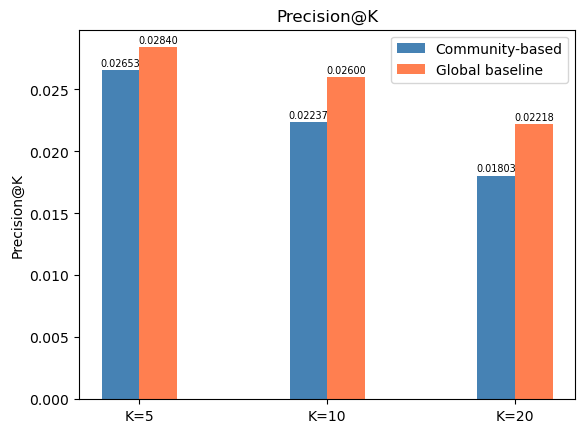

In [79]:
visualize_comparison("Precision@K")

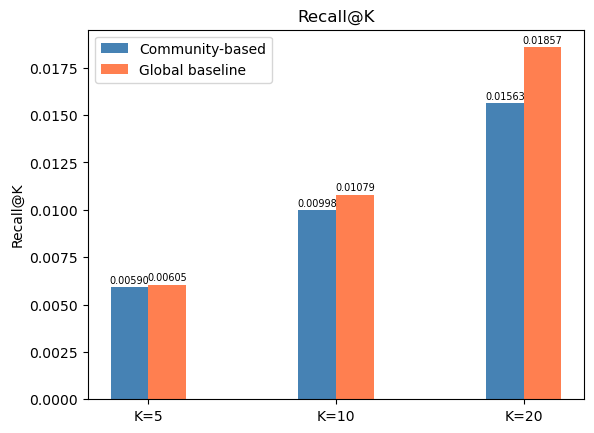

In [81]:
visualize_comparison("Recall@K")

In [83]:
# Impact of community size and density
# For each community compute: size, intra-community edge density, avg Precision@10
comm_stats = []

for comm_id, users_in_comm in train_df.groupby('community')['user_id'].apply(set).items():
    # User indices for this community
    nodes_in_g = [user_idx[u] for u in users_in_comm if u in user_idx]
    if len(nodes_in_g) < 2:
        continue

    subg = G.subgraph(nodes_in_g)
    density = nx.density(subg)

    # Precision@10 for users in this community that appear in test
    prec_vals = []
    for uid in users_in_comm:
        relevant = test_user_items.get(uid, set())
        if not relevant:
            continue
        recs = recommend_community_based(uid, 10, user_to_community, community_popular, user_seen)
        prec_vals.append(precision_at_k(recs, relevant, 10))

    if prec_vals:
        comm_stats.append({
            'community': comm_id,
            'size': len(users_in_comm),
            'density': density,
            'avg_prec@10': np.mean(prec_vals)
        })

comm_stats_df = pd.DataFrame(comm_stats)
comm_stats_df

,community,size,density,avg_prec@10
0,0,189,0.020995,0.010582
1,1,339,0.042904,0.070501
2,6,6,0.333333,0.033333
3,10,2,1.000000,0.000000
4,14,188,0.028558,0.023404
5,17,82,0.217103,0.071951
6,18,179,0.033708,0.017318
7,19,243,0.034690,0.025514
8,21,266,0.017761,0.015789
9,23,222,0.022217,0.019820


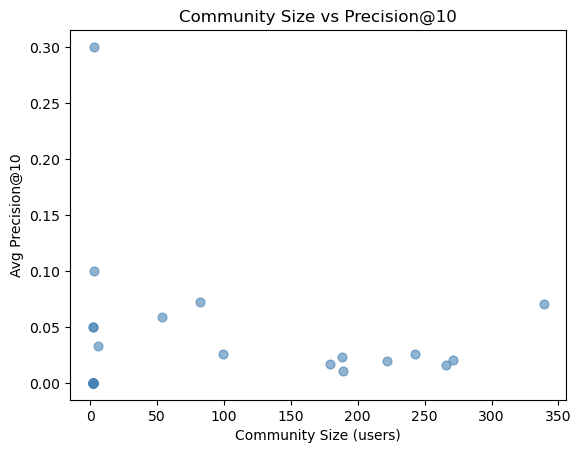

In [85]:
plt.scatter(comm_stats_df['size'], comm_stats_df['avg_prec@10'],
                alpha=0.6, color='steelblue', s=40)
plt.xlabel('Community Size (users)')
plt.ylabel('Avg Precision@10')
plt.title('Community Size vs Precision@10')
plt.savefig("commsize_vs_precision.png")
plt.show()

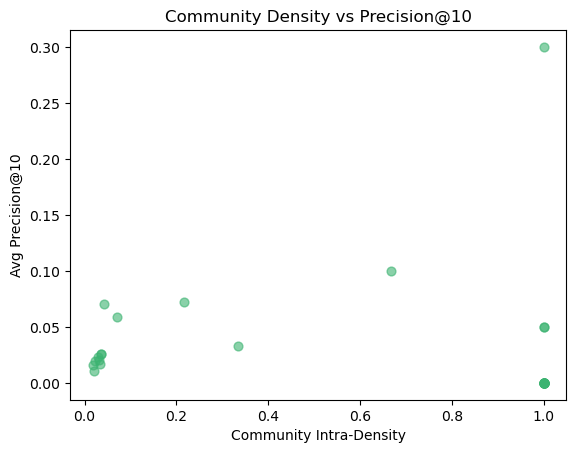

In [87]:
plt.scatter(comm_stats_df['density'], comm_stats_df['avg_prec@10'],
                alpha=0.6, color='mediumseagreen', s=40)
plt.xlabel('Community Intra-Density')
plt.ylabel('Avg Precision@10')
plt.title('Community Density vs Precision@10')
plt.savefig("commdensity_vs_precision.png")
plt.show()

In [89]:
corr_size = comm_stats_df[['size', 'avg_prec@10']].corr().iloc[0, 1]
corr_density = comm_stats_df[['density', 'avg_prec@10']].corr().iloc[0, 1]
print(f"Pearson correlation: size vs Precision@10 = {corr_size:.4f}")
print(f"Pearson correlation: density vs Precision@10 = {corr_density:.4f}")

Pearson correlation: size vs Precision@10 = -0.0442
Pearson correlation: density vs Precision@10 = 0.0064


## Task 8 - Assortativity Analysis

In [91]:
# Degree assortativity
deg_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity coefficient: {deg_assortativity:.4f}")
if deg_assortativity > 0:
    print("=> Assortative: high-degree users tend to connect with other high-degree users.")
elif deg_assortativity < 0:
    print("=> Disassortative: high-degree users tend to connect with low-degree users.")
else:
    print("=> Neutral assortativity.")

Degree assortativity coefficient: -0.0577
=> Disassortative: high-degree users tend to connect with low-degree users.


In [93]:
# 8b. Rating-based assortativity 
# Attribute: average rating per user
user_avg_rating = train_df.groupby('user_id')['rating'].mean().to_dict()

# Assign attribute to nodes (only nodes that have ratings)
for node in G.nodes():
    uid = ix_to_user.get(node)
    G.nodes[node]['avg_rating'] = user_avg_rating.get(uid, 0.0)

# Numeric attribute assortativity
rating_assortativity = nx.numeric_assortativity_coefficient(G, 'avg_rating')
print(f"Rating assortativity coefficient: {rating_assortativity:.4f}")
if rating_assortativity > 0:
    print("=> Users with similar average ratings tend to cluster together.")
else:
    print("=> No strong rating-based homophily detected.")

Rating assortativity coefficient: 0.0464
=> Users with similar average ratings tend to cluster together.


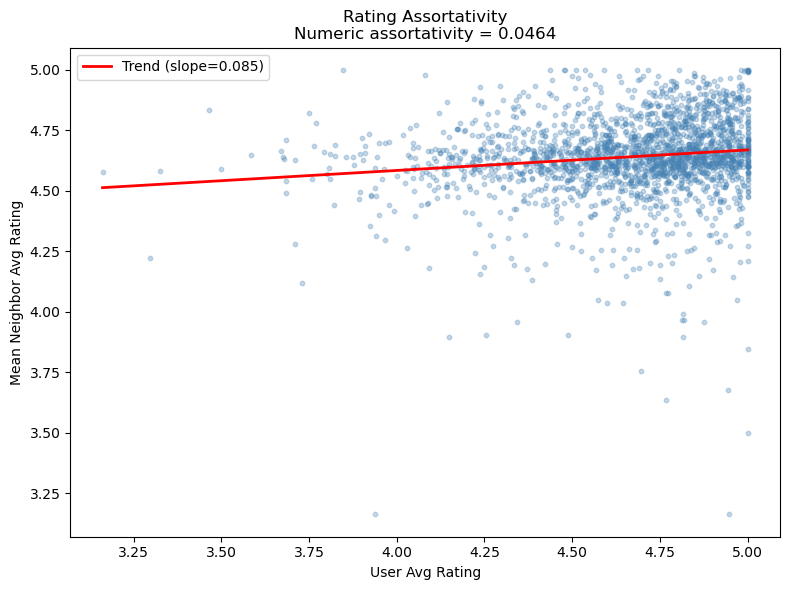

In [95]:
# 8c. Visualise: avg rating of neighbors vs avg rating of node
node_ratings = dict(G.nodes(data='avg_rating'))
neighbor_avg = {}
for node in G.nodes():
    nbrs = list(G.neighbors(node))
    if nbrs:
        neighbor_avg[node] = np.mean([node_ratings[n] for n in nbrs])

sample_nodes = list(neighbor_avg.keys())
x_r = [node_ratings[n] for n in sample_nodes]
y_r = [neighbor_avg[n]  for n in sample_nodes]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_r, y_r, alpha=0.3, s=10, color='steelblue')

# Trend line
z = np.polyfit(x_r, y_r, 1)
p = np.poly1d(z)
xline = np.linspace(min(x_r), max(x_r), 200)
ax.plot(xline, p(xline), 'r-', linewidth=2, label=f'Trend (slope={z[0]:.3f})')

ax.set_xlabel('User Avg Rating')
ax.set_ylabel('Mean Neighbor Avg Rating')
ax.set_title(f'Rating Assortativity\nNumeric assortativity = {rating_assortativity:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('task8_assortativity.png', bbox_inches='tight')
plt.show()

## Task 9 - K-core Analysis

Maximum core number: 33


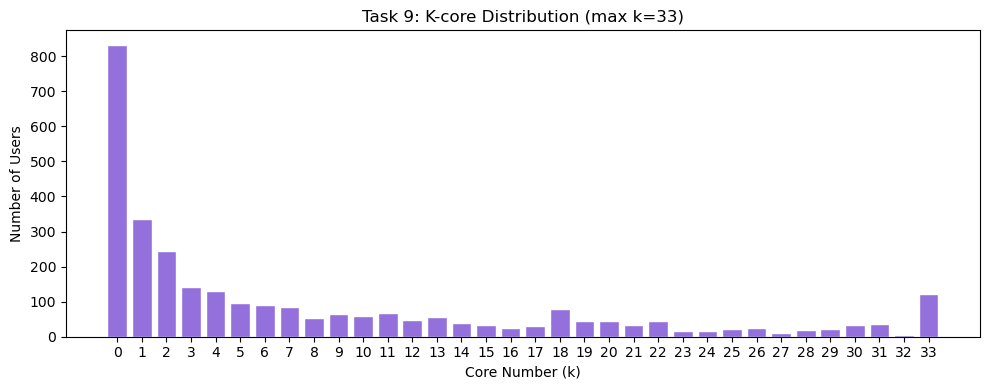

In [97]:
# K-core decomposition 
core_numbers = nx.core_number(G)
nx.set_node_attributes(G, core_numbers, 'core')

max_core = max(core_numbers.values())
print(f"Maximum core number: {max_core}")

# Distribution of core numbers
core_counts = Counter(core_numbers.values())
cores_sorted = sorted(core_counts.keys())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(k) for k in cores_sorted],
       [core_counts[k] for k in cores_sorted],
       color='mediumpurple', edgecolor='white')
ax.set_title(f'Task 9: K-core Distribution (max k={max_core})')
ax.set_xlabel('Core Number (k)')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.savefig('task9_kcore_distribution.png', bbox_inches='tight')
plt.show()

In [99]:
# Core users and their recommendation influence 
# Define core users as those in the top-k core (k >= max_core * 0.6)
CORE_THRESHOLD = max(1, int(max_core * 0.6))
core_users_ix  = {n for n, k in core_numbers.items() if k >= CORE_THRESHOLD}
core_users_ids = {ix_to_user[n] for n in core_users_ix if n in ix_to_user}

print(f"Core threshold: k >= {CORE_THRESHOLD}")
print(f"Core users: {len(core_users_ids):,} ({100*len(core_users_ids)/len(unique_users):.1f}% of all users)")

# Fraction of popular recipes (top-100 globally) that core users account for
top100_recipes = set(global_popular.head(100).index)
core_interactions = train_df[train_df['user_id'].isin(core_users_ids)]
core_top100_coverage = len(core_interactions[core_interactions['recipe_id'].isin(top100_recipes)]) \
                       / max(1, len(core_interactions))

all_top100_coverage = len(train_df[train_df['recipe_id'].isin(top100_recipes)]) \
                      / max(1, len(train_df))

print(f"Fraction of interactions on top-100 recipes:")
print(f"Core users: {core_top100_coverage:.4f}")
print(f"All users: {all_top100_coverage:.4f}")
if core_top100_coverage > all_top100_coverage:
    print("=> Core users are disproportionately concentrated on globally popular recipes.")
else:
    print("=> Core users do not show stronger concentration on globally popular recipes.")

Core threshold: k >= 19
Core users: 490 (16.3% of all users)
Fraction of interactions on top-100 recipes:
Core users: 0.1020
All users: 0.0290
=> Core users are disproportionately concentrated on globally popular recipes.


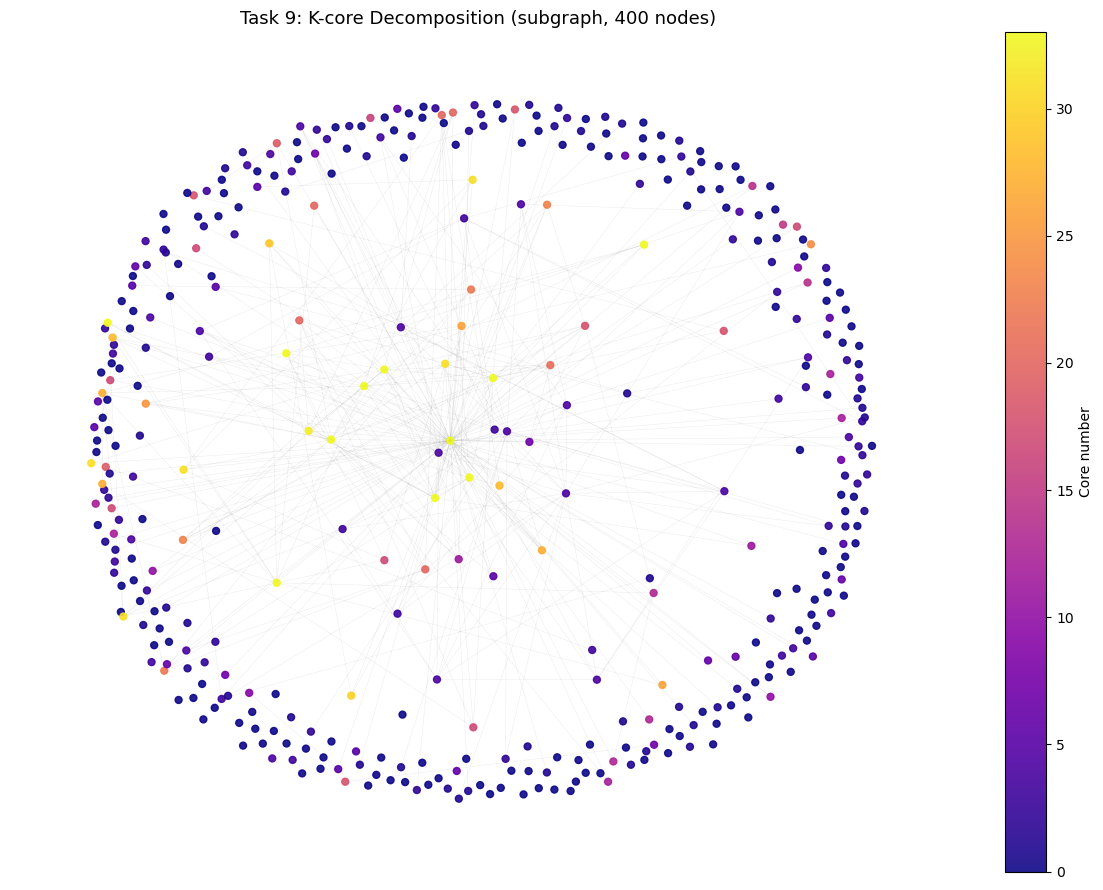

In [101]:
# Visualise k-core on a subgraph (colour by core number)
VIZ_NODES_CORE = 400
viz_nodes_c = list(G.nodes())[:VIZ_NODES_CORE]
G_viz_c = G.subgraph(viz_nodes_c).copy()

core_colors = [core_numbers.get(n, 0) for n in G_viz_c.nodes()]
pos_c = nx.spring_layout(G_viz_c, seed=RANDOM_SEED, k=0.3)

fig, ax = plt.subplots(figsize=(12, 9))
sc = nx.draw_networkx_nodes(G_viz_c, pos_c, node_color=core_colors,
                             cmap=cm.plasma, node_size=25, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_viz_c, pos_c, alpha=0.07, width=0.4, ax=ax)
plt.colorbar(sc, ax=ax, label='Core number')
ax.set_title(f'Task 9: K-core Decomposition (subgraph, {VIZ_NODES_CORE} nodes)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('task9_kcore_visualization.png', bbox_inches='tight')
plt.show()


## Task 10 - Critical Discussion

### 10.1 Community-Based vs Global Recommendation

The community-based approach leverages the structural groupings of the user-interaction network to personalise recommendations. By narrowing the candidate pool to recipes popular within a user's community, it captures latent taste clusters that reflect shared culinary preferences. In contrast, the global popularity baseline recommends the same set of recipes to everyone, ignoring any individual or group-level differences.

Whether community-based outperforms global popularity depends heavily on community quality: if Louvain communities genuinely correspond to coherent taste groups, we expect higher precision and recall. Conversely, if communities are artefacts of network construction choices (e.g. the similarity threshold), the baseline may perform comparably or better.

### 10.2 Limitations

**1. Cold-start problem.**  
New users have no rating history and therefore no position in the similarity network. They cannot be assigned to a community, making community-based recommendation impossible without a fallback strategy.

**2. Sensitivity to the similarity threshold.**  
The graph topology - and hence community structure - changes substantially with the cosine similarity threshold used to define edges. A lower threshold creates a denser graph with fewer, larger communities; a higher threshold creates a sparser graph where many users become isolated. There is no universally optimal threshold, and this hyperparameter introduces instability.

**3. Non-determinism of Louvain.**  
The Louvain algorithm uses random restarts and is not guaranteed to return the same partition across runs. Recommendation outcomes therefore vary between runs unless a fixed random seed is used and the graph structure does not change.

**4. Popularity bias within communities.**  
Recommending the most-rated recipes within a community still favours dominant tastes. Niche or novel recipes - even if highly relevant to a specific user - are systematically underrepresented. This limits serendipity and long-tail coverage.

**5. Scalability of Girvan-Newman.**  
The Girvan-Newman algorithm runs in O(m^3) time (m = number of edges), making it infeasible for the full Food.com graph. In this project it was run on a 300-node subgraph for demonstration purposes; its modularity and community structure may not generalise to the complete network.

**6. Rating sparsity.**  
The user-recipe matrix is extremely sparse. Cosine similarity between users who have rated few recipes in common may be unreliable, leading to spurious edges and noisy communities.

**7. Temporal dynamics.**  
The model is static: it ignores that user preferences evolve over time. A user's community from historical data may not reflect their current tastes, reducing recommendation relevance.

**8. Lack of content signals.**  
The user-user network is built exclusively on rating behaviour. Incorporating content signals (ingredients, cuisine, cooking time) could produce more semantically meaningful communities and better recommendations.

### Summary

| Aspect | Community-based | Global baseline |
|---|---|---|
| Personalisation | Moderate (community-level) | None |
| Cold-start handling | Poor | Good |
| Scalability | Moderate | High |
| Diversity | Low (popular within community) | Low (global popular) |
| Interpretability | Moderate | High |

In [109]:
# Final Summary 
print("PROJECT 6 — FINAL SUMMARY")
print()
print(f"\n1. Network")
print(f"- Nodes (users): {G.number_of_nodes():,}")
print(f"- Edges: {G.number_of_edges():,}")
print(f"- Density: {nx.density(G):.6f}")
print(f"- Largest CC size: {G_lcc.number_of_nodes():,} ({100*G_lcc.number_of_nodes()/n_users:.1f}%)")

print(f"\n2. Community Detection")
print(f"- Louvain communities: {n_louvain_communities}")
print(f"- Louvain modularity: {louvain_modularity:.4f}")
print(f"- GN communities (subgraph): {len(gn_communities)}")
print(f"- GN modularity (subgraph): {gn_modularity:.4f}")

print(f"\n3. Assortativity")
print(f"- Degree assortativity: {deg_assortativity:.4f}")
print(f"- Rating assortativity: {rating_assortativity:.4f}")

print(f"\n4. K-core")
print(f"- Max core number: {max_core}")
print(f"- Core users (k>={CORE_THRESHOLD}): {len(core_users_ids)}")

print(f"\n5. Evaluation (avg over {len(eval_users)} users)")
print(f"{'K':<6} {'CB Prec':>12} {'CB Recall':>12} {'GB Prec':>12} {'GB Recall':>12}")
for K in K_LIST:
    print(f"{K:<6} "
          f"{comm_results[K]['Precision@K']:>12.6f} "
          f"{comm_results[K]['Recall@K']:>12.6f} "
          f"{global_results[K]['Precision@K']:>12.6f} "
          f"{global_results[K]['Recall@K']:>12.6f}")

PROJECT 6 — FINAL SUMMARY


1. Network
- Nodes (users): 3,000
- Edges: 22,249
- Density: 0.004946
- Largest CC size: 2,138 (71.3%)

2. Community Detection
- Louvain communities: 858
- Louvain modularity: 0.2429
- GN communities (subgraph): 103
- GN modularity (subgraph): 0.2945

3. Assortativity
- Degree assortativity: -0.0577
- Rating assortativity: 0.0464

4. K-core
- Max core number: 33
- Core users (k>=19): 490

5. Evaluation (avg over 3000 users)
K           CB Prec    CB Recall      GB Prec    GB Recall
5          0.026533     0.005898     0.028400     0.006053
10         0.022367     0.009976     0.026000     0.010790
20         0.018033     0.015626     0.022183     0.018571
